# Analytical Results: Food Access in Atlanta

**Research Question:** Analyze & prioritize LILA tracts to guide Invest Atlanta's investments towards equitable Fresh Food Access by 2030.

| Plot | Finding |
|------|---------|
| 1. Correlation Heatmap | SNAP & poverty dominate need score; food business count barely matters |
| 2. LILA vs Non-LILA Box Plots | LILA tracts are statistically worse on every economic indicator |
| 3. Poverty x SNAP Scatter | The two main drivers compound each other |


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path

def _find_geojson():
    target = Path('data') / 'processed' / 'tract_level_food_access.geojson'
    for base in [Path.cwd()] + list(Path.cwd().parents):
        c = base / target
        if c.exists():
            probe = gpd.read_file(c, rows=1)
            if 'fresh_access_ratio' in probe.columns:
                return c
    raise FileNotFoundError('Full geojson not found.')

df = gpd.read_file(_find_geojson()).copy()
for c in ['PvrtyRt','TrcSNAP','marta_access_count','food_business_count',
          'need_score','has_lila','TrcSNAP_scaled','PvrtyRt_scaled',
          'food_business_gap','transit_gap']:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

print('Tracts:', len(df), '  LILA:', int(df['has_lila'].sum()))


Tracts: 211   LILA: 126


## Plot 1 — Correlation Heatmap

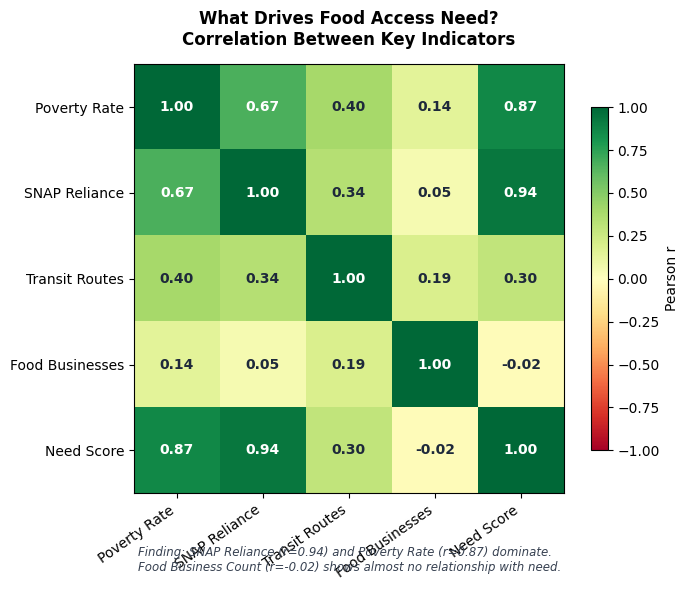

In [2]:
analysis_cols = {
    'Poverty Rate':    'PvrtyRt',
    'SNAP Reliance':   'TrcSNAP',
    'Transit Routes':  'marta_access_count',
    'Food Businesses': 'food_business_count',
    'Need Score':      'need_score',
}
corr = df[list(analysis_cols.values())].corr()
corr.index   = list(analysis_cols.keys())
corr.columns = list(analysis_cols.keys())

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('white')
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
fig.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
n = len(corr)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(corr.columns, rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(corr.index, fontsize=10)
for i in range(n):
    for j in range(n):
        val = corr.iloc[i, j]
        col = 'white' if abs(val) > 0.6 else '#1e293b'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=10, fontweight='bold', color=col)
ax.set_title('What Drives Food Access Need?\nCorrelation Between Key Indicators',
             fontsize=12, fontweight='bold', pad=14)
ax.text(0.01, -0.18,
        'Finding: SNAP Reliance (r=0.94) and Poverty Rate (r=0.87) dominate.\n'
        'Food Business Count (r=-0.02) shows almost no relationship with need.',
        transform=ax.transAxes, fontsize=8.5, color='#374151', style='italic')
plt.tight_layout()
plt.show()


## Plot 2 — LILA vs Non-LILA Box Plots

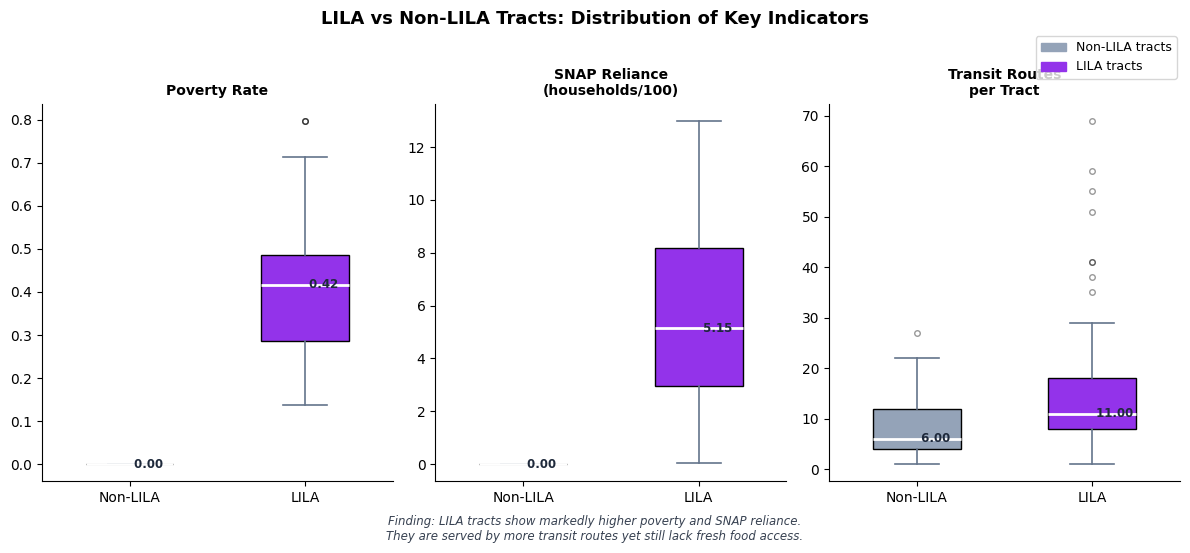

In [3]:
metrics = {
    'Poverty Rate':                    'PvrtyRt',
    'SNAP Reliance\n(households/100)': 'TrcSNAP',
    'Transit Routes\nper Tract':       'marta_access_count',
}
lila_g    = df[df['has_lila'] == 1]
non_lila_g = df[df['has_lila'] == 0]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.patch.set_facecolor('white')
for ax, (label, col) in zip(axes, metrics.items()):
    data = [non_lila_g[col].dropna(), lila_g[col].dropna()]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor('#94a3b8')
    bp['boxes'][1].set_facecolor('#9333ea')
    for w in bp['whiskers']: w.set(color='#64748b', linewidth=1.2)
    for c in bp['caps']:     c.set(color='#64748b', linewidth=1.2)
    for f in bp['fliers']:   f.set(marker='o', color='#94a3b8', alpha=0.4, markersize=4)
    for i, d in enumerate(data):
        med = np.median(d)
        ax.text(i + 1, med, f' {med:.2f}', va='center',
                fontsize=8.5, fontweight='bold', color='#1e293b')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Non-LILA', 'LILA'], fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.set_facecolor('white')
fig.legend(handles=[
    mpatches.Patch(color='#94a3b8', label='Non-LILA tracts'),
    mpatches.Patch(color='#9333ea', label='LILA tracts'),
], loc='upper right', fontsize=9, bbox_to_anchor=(0.99, 0.98))
fig.suptitle('LILA vs Non-LILA Tracts: Distribution of Key Indicators',
             fontsize=13, fontweight='bold', y=1.02)
fig.text(0.5, -0.04,
         'Finding: LILA tracts show markedly higher poverty and SNAP reliance.\n'
         'They are served by more transit routes yet still lack fresh food access.',
         ha='center', fontsize=8.5, color='#374151', style='italic')
plt.tight_layout()
plt.show()


## Plot 3 — Poverty x SNAP Scatter

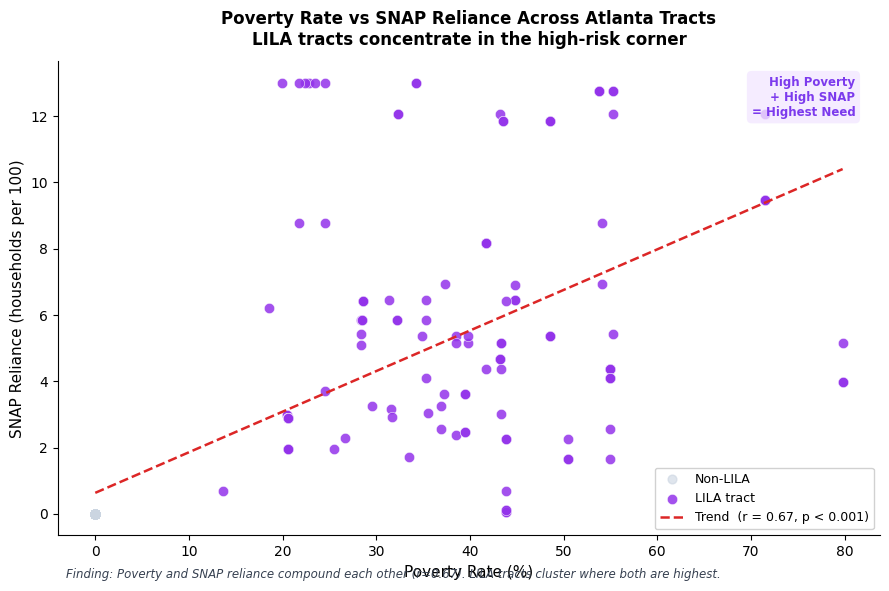

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('white')
non  = df[df['has_lila'] == 0]
lila = df[df['has_lila'] == 1]
ax.scatter(non['PvrtyRt']  * 100, non['TrcSNAP'],
           color='#cbd5e1', s=40, alpha=0.6, label='Non-LILA', zorder=2)
ax.scatter(lila['PvrtyRt'] * 100, lila['TrcSNAP'],
           color='#9333ea', s=55, alpha=0.85, edgecolors='white',
           linewidths=0.4, label='LILA tract', zorder=3)
x = df['PvrtyRt'] * 100
y = df['TrcSNAP']
slope, intercept, r, p, _ = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept,
        color='#dc2626', linewidth=1.8, linestyle='--',
        label='Trend  (r = ' + str(round(r, 2)) + ', p < 0.001)', zorder=4)
ax.text(0.97, 0.97, 'High Poverty\n+ High SNAP\n= Highest Need',
        transform=ax.transAxes, fontsize=8.5, color='#7c3aed',
        fontweight='bold', ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.4', fc='#f3e8ff', alpha=0.8, lw=0))
ax.set_xlabel('Poverty Rate (%)', fontsize=11)
ax.set_ylabel('SNAP Reliance (households per 100)', fontsize=11)
ax.set_title('Poverty Rate vs SNAP Reliance Across Atlanta Tracts\n'
             'LILA tracts concentrate in the high-risk corner',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9, framealpha=0.9)
ax.spines[['top','right']].set_visible(False)
ax.text(0.01, -0.09,
        'Finding: Poverty and SNAP reliance compound each other (r=0.67). '
        'LILA tracts cluster where both are highest.',
        transform=ax.transAxes, fontsize=8.5, color='#374151', style='italic')
plt.tight_layout()
plt.show()
